## Task 3: Generative Tasks with External Models

The **third task** we defined for our **Game Recommendation Assistant** is the following:

**RAG system with Text + Image files as Input**: Given a user query about finding a specific kind of game and an image that supports that statement, the system retrieves from the vector database using similarity search based on embeddings to find the most similar game description and image to the given data. Then, the information provided by the user and the retrieved one will be passed to a customized prompt that will later be used by an external generative model we chose. The output of the model will be a game description generated based on all the information it received previously, and the image we retrieved from the vector database will be shown as an example (these are not generated by the model).

**RAG system with Text + Video files as Input**: The idea is practically identical to the former point, but here we have a video instead of an image. Due to the lack of GPU resources, we couldn't do much here. The most difficult problem here is dealing with video inputs. What we did was divide the video into different frames (images) so we could pass them all together to the model, which means we are ignoring the audio content of the video. Even then, we were only able to extract a few frames (in the end, we decided to use only 8 frames, as more than 12 could exceed the GPU resources of Kaggle) from a video to correctly execute the generative model. The output here is also a game description plus a list of images (frames of the video).

In [1]:
# Importing useful dependencies
import io
import boto3
import torch
import imageio
import cv2 # for reading video frames
import chromadb
import requests
import open_clip
import numpy as np
from PIL import Image
from io import BytesIO
import ipywidgets as widgets
from IPython.display import display
# If you are having problems importing these functions from the transformers library, try executing them on Kaggle
from transformers import AutoProcessor, LlavaOnevisionForConditionalGeneration, CLIPVisionModelWithProjection, CLIPImageProcessor

In [2]:
# Setup S3 client for MinIO (MinIO implements Amazon S3 API)
s3 = boto3.client(
    "s3",
    endpoint_url="http://127.0.0.1:9000", # MinIO API endpoint
    aws_access_key_id="minioadmin", # User name
    aws_secret_access_key="minioadmin", # Password
)

In [3]:
# Connect to the server of ChromaDB where we stored the embeddings of files (Docker Container)
client = chromadb.HttpClient(host="localhost", port=8000)

# Create or get the collection named "texts_images"
collection_texts_images = client.create_collection(name="texts_images", get_or_create=True, embedding_function=None)

# Create or get the collection named "videos"
collection_videos = client.create_collection(name="videos", get_or_create=True, embedding_function=None)

In [4]:
# Just in case our device has gpu
device = "cuda" if torch.cuda.is_available() else "cpu"

### Model configuration

The following cell is recommended to execute using the free GPU resources provided by Kaggle. Otherwise, it's highly possible to experience a kernel crash.

In [5]:
# We will use this model as the answerer of our RAG system.
model_id = "llava-hf/llava-onevision-qwen2-0.5b-ov-hf"

# Load model + processor
model = LlavaOnevisionForConditionalGeneration.from_pretrained(
    model_id,
    dtype=torch.float16,
    low_cpu_mem_usage=True,
).to(device)
processor = AutoProcessor.from_pretrained(model_id)

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


### Text + Image Inputs

In [6]:
# Load "ViT-B-16" model for images and texts
model_it, _, preprocess_it = open_clip.create_model_and_transforms("ViT-B-16", pretrained="openai")
tokenizer_it = open_clip.get_tokenizer("ViT-B-16") # Tokenizer for texts
model_it.to(device)

D:\multi-modal-management-pipeline\.venv\Lib\site-packages\open_clip\factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


CLIP(
  (visual): VisionTransformer(
    (conv1): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16), bias=False)
    (patch_dropout): Identity()
    (ln_pre): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (transformer): Transformer(
      (resblocks): ModuleList(
        (0-11): 12 x ResidualAttentionBlock(
          (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (ls_1): Identity()
          (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): Sequential(
            (c_fc): Linear(in_features=768, out_features=3072, bias=True)
            (gelu): GELU(approximate='none')
            (c_proj): Linear(in_features=3072, out_features=768, bias=True)
          )
          (ls_2): Identity()
        )
      )
    )
    (ln_post): LayerNorm((768,), eps=1e-05, elementwise_affine

In [7]:
# Function to perform the similarity search
def find_similar_files(collection, query_emb: np.ndarray, top_k: int = 5):
    
    # Chroma expects list-of-lists for query_embeddings
    query_vector = query_emb.tolist()

    results = collection.query(
        query_embeddings=[query_vector],
        n_results=top_k,
        include=["documents", "distances"]
    )

    # Extract first query results
    ids = results.get("ids", [[]])[0]
    docs = results.get("documents", [[]])[0]
    dists = results.get("distances", [[]])[0]

    print(f"Top {top_k} similar {collection.name}:")
    for rank, (doc_id, doc, dist) in enumerate(zip(ids, docs, dists), start=1):
        print(f"{rank}. id={doc_id}, distance={dist:.4f}")
        print(f"   document: {doc}")
        temp_path = doc.split("/")[-1]
        if (collection.name == "images"):
            display(get_image("trusted-zone", f"{collection.name}/{temp_path}"))
        elif (collection.name == "texts"):
            print("\n" + get_text("trusted-zone", f"{collection.name}/{temp_path}") + "\n")
        elif (collection.name == "videos"):
            frames = get_video("trusted-zone", f"{collection.name}/{temp_path}")
            for frame in frames:
                display(frame)
    return results

**User Inputs**

In [8]:
# Let's define a user query for our RAG system
user_query = (
    "Please recommend me a game similar to the one shown in the image."
) # This do not provide any useful information for retrieving similar textual embeddings, it's too vague

In [9]:
# Here is another query that provides more insights into the problem
user_query_ex = (
    "Please recommend me an open-world action RPG game with exploration similar to the one shown in the image."
) # This query does provide information about the type of game we are looking for

In [10]:
# This is the image provided by the user
uploader = widgets.FileUpload(accept='image/*', multiple=False)
display(uploader) # Load an image first before executing the upcoming cells

FileUpload(value=(), accept='image/*', description='Upload')

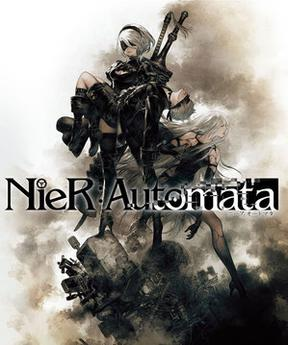

In [11]:
# Extract the uploaded file
user_image = uploader.value[0].content
user_image = Image.open(BytesIO(user_image))
user_image

**System Inputs**

In [12]:
# We can use this function to retrieve an text from our bucket
def get_text(bucket, key):
    resp = s3.get_object(Bucket=bucket, Key=key)
    body = resp["Body"].read()
    text = body.decode("utf-8")
    return text

@torch.no_grad()
# The next function returns the embedding of the given text
def embed_text(model, tokenizer, texts: str):
    tokens = tokenizer([texts]).to(device) # tokenized batch
    feats = model.encode_text(tokens)
    feats = feats / feats.norm(dim=-1, keepdim=True) # normalize
    return feats.cpu().numpy()[0]

# Retrieve from our vector database the most similar description by using the user queries
query_emb_1 = embed_text(model_it, tokenizer_it, user_query)
# Search for similar texts in ChromaDB
res_text_1 = find_similar_files(collection_texts_images, query_emb_1, top_k=1) # For efficiency, we will always choose the first option
# The collection we are using has also embeddings of images, however, the most similar files will always be that of the same modality

# Get retrieved description
retrieved_des_1 = get_text("trusted-zone", "texts/" + res_text_1['documents'][0][0].split("/")[-1])
retrieved_des_1

Top 1 similar texts_images:
1. id=text_469, distance=0.2405
   document: trusted-zone/texts/text_1761413795877.txt


"XWallpaper is a funny and powerful live wallpaper engine that displays amazing animations and effects on your wallpaper with low CPU usage. It brings life to your static wallpaper with powerful visual designer in one-click. Features Brings life to your static wallpaper with build-in Visual Live Wallpaper Designer,clean UI and easy to use Hundreds of floating particle effects(200)/filters(20) and mouse track effects(200),mouse click effects(200) to choose from. Many editing options - you can change almost every effects in live wallpaper. Pause Mode - You can enable the pause mode when you need 100% power for your other games. Support Taskbar transparent Support Multi-Monitors Support Steam Workshop Optimization - reduced equipment requirements,low CPU usage. Optimized code created for Low-end devices. Note Not compatible with Wallpaper Engine. Can't be used at the same time. WHAT CURATORS SAY OFENTM: “Интересный движок по воспроизведению анимированных обоев на рабочем столе.Поглощает м

In [13]:
# We can also have a comparison between "user_query" and "user_query_ex"
query_emb_2 = embed_text(model_it, tokenizer_it, user_query_ex)
res_text_2 = find_similar_files(collection_texts_images, query_emb_2, top_k=1)

# Get retrieved description
retrieved_des_2 = get_text("trusted-zone", "texts/" + res_text_2['documents'][0][0].split("/")[-1])
retrieved_des_2
# It seems like the sencond query leads to a better description, so in the following cells we will use this query

Top 1 similar texts_images:
1. id=text_483, distance=0.2925
   document: trusted-zone/texts/text_1761413800032.txt


"GAME STATUS DON'T BUY THIS GAME! UNLESS YOU WANT TO SUPPORT ME! This game is under heavy construction so be careful if you decide to buy it. There is limited game play exist and there are many bugs still can break the game play. You can play the latest version FREE by downloading the DEMO. If you like the game and you want to support me you can buy it. I will be very happy about it. Game is in playable condition but not finished yet. There are many implementations on the road but you can see the game's future after you play a two or there rounds. I tried to mix the Paradox Crusader Kings map play with X- Com battle mechanics with western theme. As a sole developer I tried to do my best and reached a certain acceptable status. I'm hoping to finish it in a 6 month. GAME MECHANICS Game has two different game modes. These are Turn Based Map Mode and Turn Based Battle Mode. Player starts with controlling the capital city of the state and player's main quest is making all liberated cities a

Top 1 similar texts_images:
1. id=img_904, distance=0.5525
   document: trusted-zone/images/image_1761413586804.png


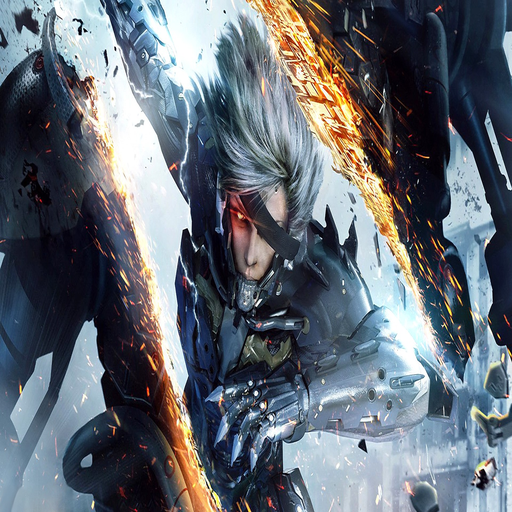

In [14]:
# We can use this function to retrieve an image from our bucket in PIL Image format
def get_image(bucket, key):
    resp = s3.get_object(Bucket=bucket, Key=key)
    body = resp["Body"].read()
    img = Image.open(io.BytesIO(body))
    return img

# The next function returns the embedding of the given PIL Image
def embed_image(preprocess, model, pil_img):
    img_tensor = preprocess(pil_img).unsqueeze(0).to(device)
    with torch.no_grad():
        feats = model.encode_image(img_tensor)
    feats = feats / feats.norm(dim=-1, keepdim=True)
    return feats.cpu().numpy().squeeze()

# Compute the embeddings of the user image
user_image_emb = embed_image(preprocess_it, model_it, user_image)
# Retrived similar image
res_image = find_similar_files(collection_texts_images, user_image_emb, top_k=1)

# Get retrieved image
retrieved_image = get_image("trusted-zone", "images/" + res_image['documents'][0][0].split("/")[-1])
retrieved_image

**Recommending Games**

In [18]:
def get_multimodal_prompt(description, user_query):
    multimodal_prompt = [
        {
            "role": "system",
            "content": [
                {"type": "text", "text": "You are a Game Recommendation Assistant, an expert in games."},
                {"type": "text", "text": "The user will ask you to recommend a game based on the user's request and an image."},
                {"type": "text", "text": "Your task is to generate a game description of similar type."},
                {"type": "text", "text": "You can use the following description and image as examples:"},
                {"type": "text", "text": description},
                {"type": "image"}, # <- first placeholder for images
            ],
        },
        {
            "role": "user",
            "content": [
                {"type": "text", "text": f"Generate a game description based on this request:\n{user_query}"},
                {"type": "image"} # <- second placeholder for images
            ],
        },
    ]

    return multimodal_prompt

# Get multimodal_prompt
multimodal_prompt = get_multimodal_prompt(retrieved_des_1, user_query) # <- include the retrieved description and user query here

Setting `pad_token_id` to `eos_token_id`:151645 for open-end generation.



🎮 Model Recommendation:
The image depicts a futuristic battle scene with a futuristic robot

Here you have an image of the game: 


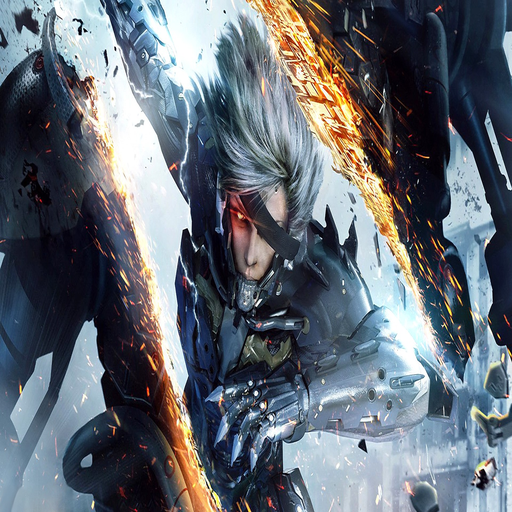

In [19]:
# Image list to feed the processor of the model
images_list = [retrieved_image, user_image] # The first image corresponds to the retrieved one, the second is the user's

# Apply template
prompt = processor.apply_chat_template(multimodal_prompt, add_generation_prompt=True)

# Prepare inputs
inputs = processor(
    text=prompt,
    images=images_list, # must match number of placeholders
    return_tensors="pt"
).to(device, torch.float16)

# Generate answer and decode
output = model.generate(**inputs, max_new_tokens=200, do_sample=False)
decoded = processor.decode(output[0], skip_special_tokens=True)

# Clean out possible prompt leftovers like "assistant" or special tokens
clean_output = decoded.split("assistant\n")[-1].strip()
clean_output = clean_output.replace(processor.image_token, "").strip()

print("\n🎮 Model Recommendation:")
print(clean_output)
print("\nHere you have an image of the game: ")
display(retrieved_image) # The result might not be good, since we may not have that image in the database

### Text + Video Inputs

**User Inputs**

In [ ]:
# New user query
user_query_v_ex = (
    "Please recommend me an open-world action RPG game with exploration similar to the one shown in the video."
) # This query does provide information about the type of game we are looking for

In [ ]:
# In this case, it similar to using images. Here we use a list of images, the frames of a video.
# This is done since LlaVa models does not treat videos as an audiovisual experience, it does not take into account audio content of videos.

# First we need to extract frames from the video (using all frames might be too much for the model we are using)
def extract_video_frames(video_path, interval=1.0):
    """Extract one frame every `interval` seconds as PIL images."""
    cap = cv2.VideoCapture(video_path)
    fps = cap.get(cv2.CAP_PROP_FPS) or 30 # default to 30 if unknown
    step = int(fps * interval)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    frames = []

    for i in range(0, total, step):
        cap.set(cv2.CAP_PROP_POS_FRAMES, i)
        ok, frame = cap.read()
        if not ok:
            break
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        frames.append(Image.fromarray(frame))

    cap.release()
    return frames

# Imagine here we have a video provided by the user
video_path = "https://cdn.akamai.steamstatic.com/steam/apps/256863704/movie_max.mp4?t=1638854607"
user_frames = extract_video_frames(video_path, interval=15.0) # 1 frame every 15 seconds -> we do not enough gpu resources to run a long list of images
print(f"Extracted {len(user_frames)} frames")

In [ ]:
# Load the model used to create embeddings of videos to create embeddings of the user video

# Load model + preprocessing used when creating the video embeddings
tokenizer_video = CLIPImageProcessor.from_pretrained("Searchium-ai/clip4clip-webvid150k")
model_video = CLIPVisionModelWithProjection.from_pretrained("Searchium-ai/clip4clip-webvid150k")
model_video.to(device)

**System Video**

In [ ]:
query_emb_3 = embed_text(model_it, tokenizer_it, user_query_v_ex)
res_text_3 = find_similar_files(collection_texts_images, query_emb_3, top_k=1)

# Get retrieved description
retrieved_des_3 = get_text("trusted-zone", "texts/" + res_text_3['documents'][0][0].split("/")[-1])
retrieved_des_3 # Not very different from the previous one, since we only changed a word (image -> video).

In [ ]:
temp_file = "temp_video_in.mp4"
# We can use the following function to retrieve a video from our MinIO database
# We are only extracting frames of the video, ignoring the audio content of the video
def get_video(bucket = None, key = None, max_frames = 8, url = None):
    if url:
        r = requests.get(url, stream=True)
        r.raise_for_status()
        with open(temp_file, "wb") as f:
            f.write(r.content)
    else:
        resp = s3.get_object(Bucket=bucket, Key=key)
        body = resp["Body"].read()
        with open(temp_file, "wb") as f:
            f.write(body)
    frames = []
    reader = imageio.get_reader(temp_file, format="ffmpeg")
    total_frames = reader.count_frames()
    if total_frames and total_frames > 0:
        step = max(1, total_frames // max_frames)
        #print(total_frames, step, max_frames)
        idxs = list(range(0, total_frames, step))[:max_frames]
        for i in idxs:
            try:
                frame = reader.get_data(i)
                frames.append(Image.fromarray(frame))
            except Exception:
                continue
    else:
        # fallback: iterate and collect up to max_frames
        for i, frame in enumerate(reader):
            frames.append(Image.fromarray(frame))
            if len(frames) >= max_frames:
                break
    reader.close()
    return frames

# The next function returns the embedding of the given video
def embed_video(tokenizer, model, frames_video):
    inputs = tokenizer(images=frames_video, return_tensors="pt")
    pixel_values = inputs["pixel_values"].to(device) # shape (num_frames, 3, H, W)

    with torch.no_grad():
        outputs = model(pixel_values=pixel_values)
        # prefer pooler_output if available, else mean over last_hidden_state
        emb_frames = getattr(outputs, "pooler_output", None)
        if emb_frames is None:
            emb_frames = outputs.last_hidden_state.mean(dim=1)
        # average frame embeddings to make video embedding
        video_emb = emb_frames.mean(dim=0).cpu().numpy()
    return  video_emb

# Create embeddings for the user video
frames_emb = embed_video(tokenizer_video, model_video, user_frames)
# Search for the most similar video in ChromaDB
res_video = find_similar_files(collection_videos, frames_emb, top_k=1)

# Get retrieved video frames
retrieved_frames = get_video("trusted-zone", "videos/" + res_video['documents'][0][0].split("/")[-1])

**Recommending Games**

In [ ]:
def get_multimodal_prompt_videos(description, user_query):
    multimodal_prompt = [
        {
            "role": "system",
            "content": [
                {"type": "text", "text": "You are a Game Recommendation Assistant, an expert in games."},
                {"type": "text", "text": "The user will ask you to recommend a game based on a textual description and a list of in-game images."},
                {"type": "text", "text": "Your task is to generate a game description of similar type."},
                {"type": "text", "text": "You can use the following description and images as examples:"},
                {"type": "text", "text": description},
                {"type": "video1"}, # <- first placeholder for images
            ],
        },
        {
            "role": "user",
            "content": [
                {"type": "text", "text": f"Generate a game description based on this request:\n{user_query}"},
                {"type": "video2"} # <- second placeholder for images
            ],
        },
    ]

    return multimodal_prompt

# Get multimodal_prompt
multimodal_prompt_v = get_multimodal_prompt_videos(retrieved_des_3, user_query_v_ex) # <- include the retrieved description and user query here

In [ ]:
# Create as many image placeholders as the number of frames 
def expand_video_placeholders(prompt, frames_per_video, placeholder="video1"):
    """
    Replace every {"type":"video"} entry with frames_per_video many {"type":"image"} placeholders.
    Returns new_prompt and the count of image placeholders produced by expansion.
    """
    new_prompt = []
    for turn in prompt:
        new_turn = {"role": turn["role"], "content": []}
        for item in turn.get("content", []):
            if item.get("type") == placeholder:
                # replace with N image placeholders
                for _ in range(len(frames_per_video)):
                    new_turn["content"].append({"type":"image"})
            else:
                new_turn["content"].append(item)
        new_prompt.append(new_turn)
    return new_prompt

# Expand the prompt:
video_prompt = expand_video_placeholders(multimodal_prompt_v, retrieved_frames) # <- Video frames of the retrieved video
video_prompt = expand_video_placeholders(video_prompt, user_frames, placeholder = "video2") # Video frames of the user video

In [ ]:
# List of images (frames from both videos)
images_list = retrieved_frames + user_frames

# Use the expanded prompt and images with the processor
prompt = processor.apply_chat_template(video_prompt, add_generation_prompt=True)

# Prepare inputs
inputs = processor(
    text=prompt,
    images=images_list, # must match number of placeholders
    return_tensors="pt"
).to(device, torch.float16)

# Generate
output = model.generate(**inputs, max_new_tokens=200, do_sample=False)
decoded = processor.decode(output[0], skip_special_tokens=True)

# Clean out possible prompt leftovers like "assistant" or special tokens
clean_output = decoded.split("assistant\n")[-1].strip()
clean_output = clean_output.replace(processor.image_token, "").strip()

print("\n🎮 Model Recommendation:")
print(clean_output)
print("\nHere you have a video (list of selected frames) of the game: ")
for frame in retrieved_frames:
    display(frame) # Retrieved one